# Aerolinea_Fidelidad_PY
### ¿Qué perfil tiene el cliente más valioso del programa de fidelización?

---

Una aerolínea tiene dos opciones para crecer: captar nuevos clientes o retener a los que ya tiene.  
Retener a un cliente es siempre más barato que captar uno nuevo.

Este análisis identifica quién es ese cliente de alto valor, dónde vive y cuánto vuela —  
para que la aerolínea sepa exactamente dónde invertir.

---

**Dataset:** 2 archivos del programa de fidelización de una aerolínea canadiense  
**Herramienta:** Python · Pandas · Seaborn  

---
## Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Configuración

In [2]:
data_path   = "data"    # CSVs originales — nunca se modifican
output_path = "output"  # resultados del proceso
os.makedirs(output_path, exist_ok=True)

---
## Fase 0 · Comprensión de los datos

En este proyecto trabajamos con dos archivos que, juntos, nos permiten entender cómo son los clientes y cómo usan el programa de fidelidad de la aerolínea.

---

### 📂 Customer_Flight_Activity.csv

Este archivo explica **qué hace cada cliente cada mes**. Incluye:

- Identificador del cliente (**Loyalty Number**)
- Año (**Year**) y mes (**Month**) del registro
- Vuelos reservados (**Flights Booked**)
- Vuelos con acompañantes (**Flights with Companions**)
- Total de vuelos acumulados (**Total Flights**)
- Distancia volada (**Distance**)
- Puntos ganados (**Points Accumulated**)
- Puntos gastados (**Points Redeemed**)
- Valor en dólares de los puntos gastados (**Dollar Cost Points Redeemed**)

**Variables clave para este análisis:** `total_flights`

---

### 📂 Customer_Profile.csv

Este archivo explica **cómo es cada cliente**. Incluye:

- Identificador del cliente (**Loyalty Number**)
- País (**Country**), provincia (**Province**), ciudad (**City**) y código postal (**Postal Code**)
- Género (**Gender**)
- Nivel educativo (**Education**)
- Salario anual (**Salary**)
- Estado civil (**Marital Status**)
- Tipo de tarjeta de fidelidad (**Loyalty Card**) — Star, Nova o Aurora
- Valor total del cliente (**CLV** — Customer Lifetime Value)
- Tipo de inscripción (**Enrollment Type**)
- Año y mes de inscripción (**Enrollment Year**, **Enrollment Month**)
- Año y mes de cancelación, si aplica (**Cancellation Year**, **Cancellation Month**)

Con este archivo conocemos el perfil demográfico del cliente, su nivel de ingresos y qué posición ocupa dentro del programa de fidelización.

**Variables clave para este análisis:** `loyalty_card`, `clv`, `province`

---
## Fase 1 · Exploración y limpieza

Revisamos y limpiamos cada archivo por separado antes de unirlos.  
Esquema aplicado: **dimensión → tipos de datos y nulos → inspección → calidad → limpieza → guardar**

---
### 📂 Customer_Flight_Activity.csv

#### 1️⃣ Dimensión 

In [3]:
# ¿cuántos registros y variables tiene el archivo?
flight_raw = pd.read_csv(os.path.join(data_path, "Customer_Flight_Activity.csv"))

print(f"Filas:    {flight_raw.shape[0]:,}")
print(f"Columnas: {flight_raw.shape[1]}")
print("Columnas:", flight_raw.columns.tolist())

Filas:    405,624
Columnas: 10
Columnas: ['Loyalty Number', 'Year', 'Month', 'Flights Booked', 'Flights with Companions', 'Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed']


#### 2️⃣ Tipos de datos y valores nulos

In [4]:
# Qué tipo de dato tiene cada columna y si hay valores faltantes
flight_raw.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


#### 3️⃣ Inspección — primeros y últimos registros

In [5]:
# Primeras filas — estructura general del archivo

print(flight_raw.head()) 

   Loyalty Number  Year  Month  Flights Booked  Flights with Companions  \
0          100018  2017      1               3                        0   
1          100102  2017      1              10                        4   
2          100140  2017      1               6                        0   
3          100214  2017      1               0                        0   
4          100272  2017      1               0                        0   

   Total Flights  Distance  Points Accumulated  Points Redeemed  \
0              3      1521               152.0                0   
1             14      2030               203.0                0   
2              6      1200               120.0                0   
3              0         0                 0.0                0   
4              0         0                 0.0                0   

   Dollar Cost Points Redeemed  
0                            0  
1                            0  
2                            0  
3             

In [6]:
 # Últimas filas — detecta registros corruptos al final ( carga correcta)

print(flight_raw.tail())

        Loyalty Number  Year  Month  Flights Booked  Flights with Companions  \
405619          999902  2018     12               0                        0   
405620          999911  2018     12               0                        0   
405621          999940  2018     12               3                        0   
405622          999982  2018     12               0                        0   
405623          999986  2018     12               0                        0   

        Total Flights  Distance  Points Accumulated  Points Redeemed  \
405619              0         0                 0.0                0   
405620              0         0                 0.0                0   
405621              3      1233               123.0                0   
405622              0         0                 0.0                0   
405623              0         0                 0.0                0   

        Dollar Cost Points Redeemed  
405619                            0  
405620    

#### 4️⃣ Calidad 

In [7]:
# duplicados y valores anómalos
print(f"Duplicados: {flight_raw.duplicated().sum():,}")

Duplicados: 1,864


#### 5️⃣ Limpieza

In [8]:
# creamos una copia, eliminando duplicados
flight_clean = flight_raw.drop_duplicates().copy()

# Nombres a snake_case — estándar en Python, evita errores con espacios y problemas con minúsculas/mayúsculas
flight_clean.columns = flight_clean.columns.str.lower().str.replace(" ", "_")

# Selección de columnas relevantes para este análisis
columnas_flight = ['loyalty_number','total_flights']
flight_clean = flight_clean[columnas_flight].copy()

print(f"Registros tras limpieza: {flight_clean.shape[0]:,}")
print(f"Columnas seleccionadas:  {flight_clean.columns.tolist()}")
print("✅ Duplicados eliminados · Columnas normalizadas · Variables seleccionadas")

Registros tras limpieza: 403,760
Columnas seleccionadas:  ['loyalty_number', 'total_flights']
✅ Duplicados eliminados · Columnas normalizadas · Variables seleccionadas


#### 6️⃣ Guardar

In [9]:
# revisamos con info la aplicación correcta de la limpieza
flight_clean.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 403760 entries, 0 to 405623
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   loyalty_number  403760 non-null  int64
 1   total_flights   403760 non-null  int64
dtypes: int64(2)
memory usage: 9.2 MB


In [10]:
flight_clean.to_csv(os.path.join(output_path, "flight_clean.csv"), index=False)
print("flight_clean.csv guardado")

flight_clean.csv guardado


---
### 📂 Customer_Profile.csv

#### 1️⃣ Dimensión 

In [11]:
# ¿Cuántos clientes y variables tiene el archivo?
profile_raw = pd.read_csv(os.path.join(data_path, "Customer_Profile.csv"))

print(f"Filas:    {profile_raw.shape[0]:,}")
print(f"Columnas: {profile_raw.shape[1]}")
print("Columnas:", profile_raw.columns.tolist())

Filas:    16,737
Columnas: 16
Columnas: ['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'Cancellation Month']


#### 2️⃣ Tipos de datos y valores nulos

In [12]:
# Qué tipo de dato tiene cada columna y si hay valores faltantes
profile_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

#### 3️⃣ Inspección — primeros y últimos registros

In [13]:
# observamos valores NAN en algunas variables
print(profile_raw.head())

   Loyalty Number Country          Province       City Postal Code  Gender  \
0          480934  Canada           Ontario    Toronto     M2Z 4K1  Female   
1          549612  Canada           Alberta   Edmonton     T3G 6Y6    Male   
2          429460  Canada  British Columbia  Vancouver     V6E 3D9    Male   
3          608370  Canada           Ontario    Toronto     P1W 1K4    Male   
4          530508  Canada            Quebec       Hull     J8Y 3Z5    Male   

  Education    Salary Marital Status Loyalty Card      CLV Enrollment Type  \
0  Bachelor   83236.0        Married         Star  3839.14        Standard   
1   College       NaN       Divorced         Star  3839.61        Standard   
2   College       NaN         Single         Star  3839.75        Standard   
3   College       NaN         Single         Star  3839.75        Standard   
4  Bachelor  103495.0        Married         Star  3842.79        Standard   

   Enrollment Year  Enrollment Month  Cancellation Year  Cance

In [14]:
# Observamos valores NaN en salary y un valor negativo.
# Los NaN parecen informativos — no todo el mundo aporta su salario.
# El valor negativo en salary parece un error de registro.
# Salary no entra en el análisis, por lo que no es necesario tratarlos.
print(profile_raw.tail())

       Loyalty Number Country          Province        City Postal Code  \
16732          823768  Canada  British Columbia   Vancouver     V6E 3Z3   
16733          680886  Canada      Saskatchewan      Regina     S1J 3C5   
16734          776187  Canada  British Columbia   Vancouver     V5R 1W3   
16735          906428  Canada             Yukon  Whitehorse     Y2K 6R0   
16736          652627  Canada          Manitoba    Winnipeg     R2C 0M5   

       Gender Education   Salary Marital Status Loyalty Card       CLV  \
16732  Female   College      NaN        Married         Star  61850.19   
16733  Female  Bachelor  89210.0        Married         Star  67907.27   
16734    Male   College      NaN         Single         Star  74228.52   
16735    Male  Bachelor -57297.0        Married         Star  10018.66   
16736  Female  Bachelor  75049.0        Married         Star  83325.38   

      Enrollment Type  Enrollment Year  Enrollment Month  Cancellation Year  \
16732        Standard    

#### 5️⃣ Limpieza

In [15]:
# creamos una copia
profile_clean = profile_raw.drop_duplicates().copy()

# Nombres a snake_case
profile_clean.columns = profile_clean.columns.str.lower().str.replace(" ", "_")

# Selección de columnas relevantes para este análisis
columnas_profile = ['loyalty_number','loyalty_card', 'clv', 'province']
profile_clean = profile_clean[columnas_profile].copy()

# Normalizar texto — evita duplicados por mayúsculas o espacios
for col in profile_clean.select_dtypes(include='object').columns:
        profile_clean[col] = profile_clean[col].str.lower().str.strip()

print(f"Registros tras limpieza: {profile_clean.shape[0]:,}")
print(f"Columnas seleccionadas:  {profile_clean.columns.tolist()}")
print("✅ Duplicados eliminados · Columnas normalizadas · Variables seleccionadas")

Registros tras limpieza: 16,737
Columnas seleccionadas:  ['loyalty_number', 'loyalty_card', 'clv', 'province']
✅ Duplicados eliminados · Columnas normalizadas · Variables seleccionadas


#### 6️⃣ Guardar

In [16]:
profile_clean.to_csv(os.path.join(output_path, "profile_clean.csv"), index=False)
print("profile_clean.csv guardado")

profile_clean.csv guardado


---
## Fase 2 · ¿Cómo es el cliente típico?

Analizamos cada variable clave por separado para construir el perfil base del cliente.  
Tres preguntas concretas: cuánto vuela, cuánto vale y dónde vive.

> El tipo de variable determina la herramienta:
> - **Continua** → media, mediana, histograma + boxplot
> - **Categórica** → value_counts(), barras (> 4 categorías) o quesito (≤ 4 categorías)

### 2.1 · `total_flights` — ¿Cuánto vuela un cliente de forma habitual?

Variable continua. Mide la actividad mensual del cliente dentro del programa.

In [17]:
print(flight_clean['total_flights'].describe().round(2))

count    403760.00
mean          5.17
std           6.53
min           0.00
25%           0.00
50%           1.00
75%          10.00
max          32.00
Name: total_flights, dtype: float64


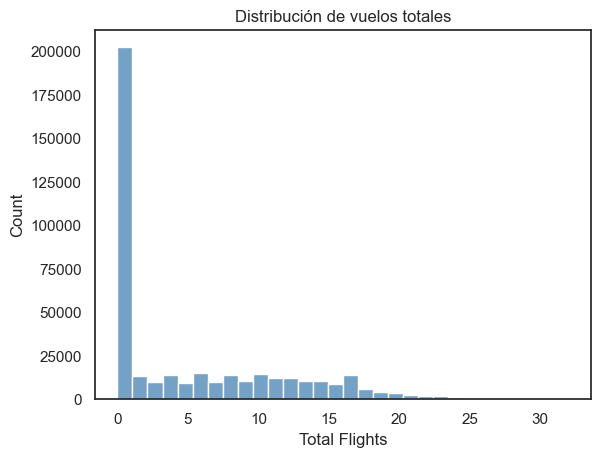

In [18]:
sns.set_theme(style="white")
sns.histplot(flight_clean['total_flights'], bins=30, color="steelblue")
plt.title("Distribución de vuelos totales")
plt.xlabel("Total Flights")
plt.show()

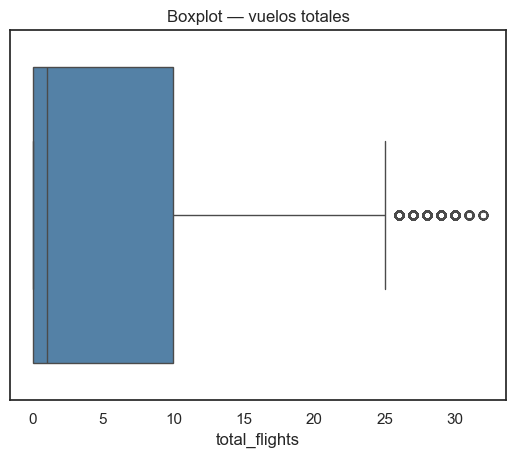

In [19]:
sns.boxplot(x=flight_clean['total_flights'], color="steelblue")
plt.title("Boxplot — vuelos totales")
plt.show()

> **Conclusión:** El 50% de nuestros clientes vuela una vez al mes o menos. Hay un grupo reducido con actividad muy alta. La mediana es más representativa que la media por la presencia de valores atípicos (outliers).

### 2.2 · `clv` — ¿Cuánto vale el cliente para la aerolínea?

Variable continua. El CLV es el valor total que aporta un cliente a la empresa a lo largo del tiempo.

In [20]:
print(profile_clean['clv'].describe().round(2))

count    16737.00
mean      7988.90
std       6860.98
min       1898.01
25%       3980.84
50%       5780.18
75%       8940.58
max      83325.38
Name: clv, dtype: float64


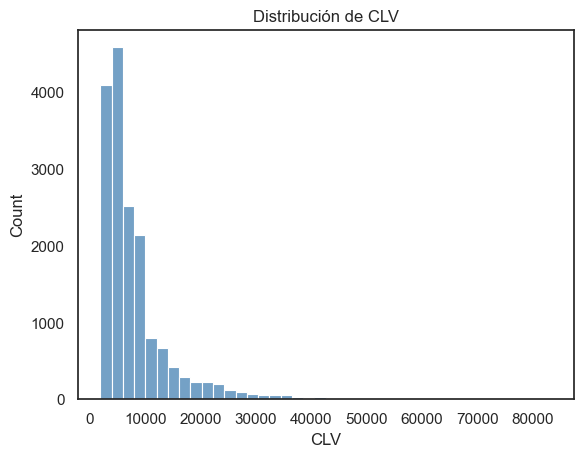

In [21]:
sns.histplot(profile_clean['clv'], bins=40, color="steelblue")
plt.title("Distribución de CLV")
plt.xlabel("CLV")
plt.show()

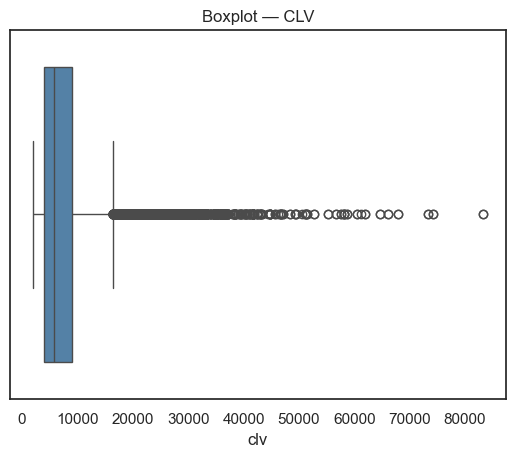

In [22]:
sns.boxplot(x=profile_clean['clv'], color="steelblue")
plt.title("Boxplot — CLV")
plt.show()

> **Conclusión:** El 50% de nuestros clientes aporta de beneficio 5780.18 al negocio. Hay un pequeño grupo de clientes muy valiosos que da mucho más dinero (hasta 83.325,38 €). Son el segmento a retener.

### 2.3 · `province` — ¿Dónde viven los clientes?

Variable categórica con 11 valores. Permite identificar los mercados con mayor base de clientes.

In [23]:
prov = profile_clean['province'].value_counts()
print((prov / prov.sum() * 100).round(1))

province
ontario                 32.3
british columbia        26.3
quebec                  19.7
alberta                  5.8
manitoba                 3.9
new brunswick            3.8
nova scotia              3.1
saskatchewan             2.4
newfoundland             1.5
yukon                    0.7
prince edward island     0.4
Name: count, dtype: float64


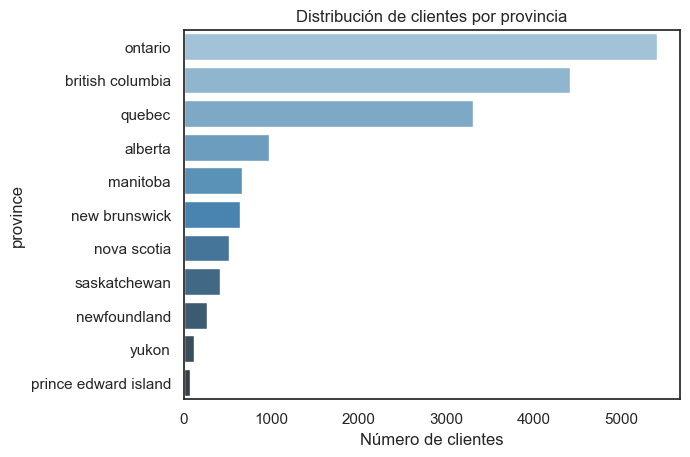

In [24]:
sns.barplot(x=prov.values, y=prov.index, hue=prov.index, palette="Blues_d", legend=False)
plt.title("Distribución de clientes por provincia")
plt.xlabel("Número de clientes")
plt.show()

> **Conclusión:** Ontario (32,29%) y British Columbia (26,34%) concentran el 58,6% de los clientes.

---
## Fase 3 · Merge

Con los datos explorados y limpios, unimos los dos archivos en un único DataFrame.

Usamos **LEFT JOIN** — conservamos toda la actividad de vuelo y añadimos el perfil cuando existe.

In [25]:
flight_clean['loyalty_number'] = flight_clean['loyalty_number'].astype(str)
profile_clean['loyalty_number'] = profile_clean['loyalty_number'].astype(str)

# Establecer la relación entre los diferentes csv en el merge con validate='m:1': 
# 1 cliente puede volar más de una vez. 
# Resultado del merge, duplicado de clientes.
# Razón: en un merge 1:m, se duplica el lado One. 
# Duplicados “lógicos” (NO son errores), por tanto no se eliminan
df_aerolinea = flight_clean.merge(profile_clean, on='loyalty_number', how='left', validate='m:1')

print(f"Filas:    {df_aerolinea.shape[0]:,}")
print(f"Columnas: {df_aerolinea.shape[1]}")
print(f"Clientes únicos: {df_aerolinea['loyalty_number'].nunique():,}")
print("✅ Merge completado")

Filas:    403,760
Columnas: 5
Clientes únicos: 16,737
✅ Merge completado


In [26]:
df_aerolinea.to_csv(os.path.join(output_path, "df_aerolinea.csv"), index=False)
print("df_aerolinea.csv guardado")

df_aerolinea.csv guardado


> **Resultado:** Cada registro de vuelo tiene ahora el perfil completo del cliente.

---
## Fase 4 · ¿Quién es el cliente más valioso?

### ❓ Pregunta 1 · ¿Aurora vale más? — `clv` + `loyalty_card`

Confirmamos si Aurora concentra mayor CLV y vuela más que el resto de segmentos.

In [27]:
clv_por_tarjeta = df_aerolinea.groupby('loyalty_card')['clv'].median().sort_values(ascending=False).round(0)
print("CLV mediano por tarjeta:")
print(clv_por_tarjeta)

CLV mediano por tarjeta:
loyalty_card
aurora    8132.0
nova      5793.0
star      4786.0
Name: clv, dtype: float64


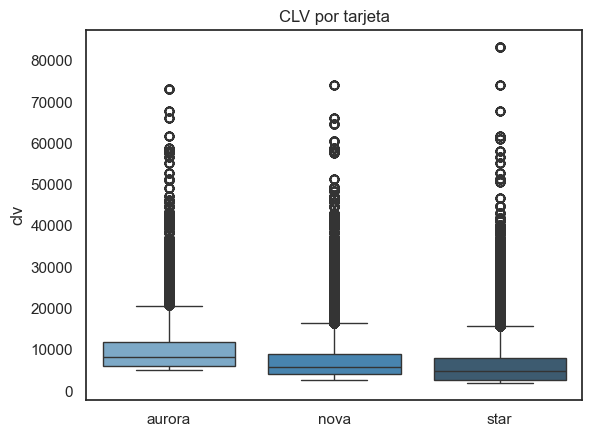

In [28]:
orden_clv = clv_por_tarjeta.index

sns.boxplot(data=df_aerolinea, x='loyalty_card', y='clv', order=orden_clv, hue='loyalty_card', palette="Blues_d", legend=False)
plt.title("CLV por tarjeta")
plt.xlabel("")
plt.show()

### ❓ Pregunta 2 · ¿Aurora vuela más? — `total_flights` + `loyalty_card`

In [29]:
print("Vuelos medianos por tarjeta:")
print(df_aerolinea.groupby('loyalty_card')['total_flights'].median().sort_values(ascending=False).round(1))

Vuelos medianos por tarjeta:
loyalty_card
aurora    2.0
nova      1.0
star      1.0
Name: total_flights, dtype: float64


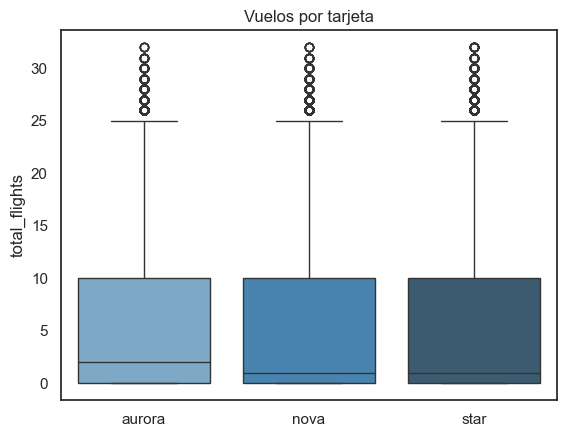

In [30]:
sns.boxplot(data=df_aerolinea, x='loyalty_card', y='total_flights', order=orden_clv, hue='loyalty_card', palette="Blues_d", legend=False)
plt.title("Vuelos por tarjeta")
plt.xlabel("")
plt.show()

> 💡 **Conclusión:**  
Aurora tiene el CLV más alto, por lo que es el segmento más valioso para la aerolínea. En cuanto a vuelos, la diferencia con Star y Nova es mínima (apenas 1-2 vuelos al mes). La razón para retener a un cliente Aurora es su valor económico, no su frecuencia de vuelo. Nos interesa retener a Aurora para que no se vaya a la competencia, ofreciendo beneficios exclusivos: entrar al avión antes que el resto de pasajeros, acceder a salas privadas en el aeropuerto con comida y descanso, mejorar de clase de asiento sin coste adicional, entre otros.

### ❓ Pregunta 3 · ¿Dónde está concentrado Aurora? — `province`+ `loyalty_card`

Comparamos la distribución geográfica de Aurora frente al resto.

In [31]:
# 'aurora' en minúsculas — coherente con la normalización aplicada en la limpieza
aurora = df_aerolinea[df_aerolinea['loyalty_card'] == 'aurora']

aurora_prov = aurora['province'].value_counts(normalize=True).mul(100).round(1)
print(aurora_prov)

province
ontario                 33.1
british columbia        26.2
quebec                  19.2
alberta                  6.2
manitoba                 4.2
new brunswick            3.2
nova scotia              3.1
saskatchewan             2.4
newfoundland             1.5
yukon                    0.5
prince edward island     0.3
Name: proportion, dtype: float64


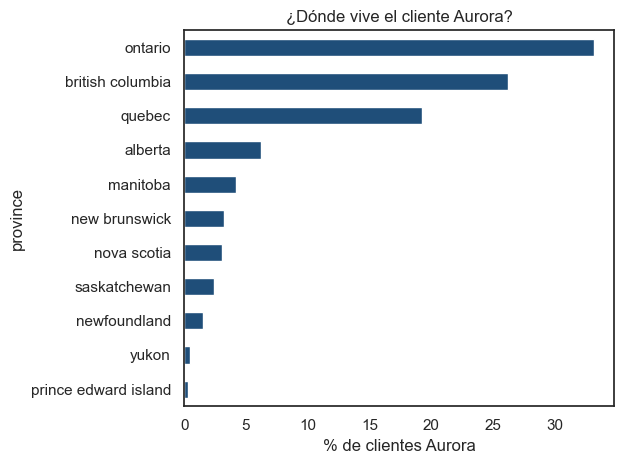

In [32]:
aurora_prov.sort_values().plot(kind='barh', color='#1f4e79')
plt.title("¿Dónde vive el cliente Aurora?")
plt.xlabel("% de clientes Aurora")
plt.tight_layout()
plt.show()

> 💡 **Conclusión:** Ontario y British Columbia concentran la mayoría de los clientes Aurora, aunque lo mismo ocurre con el resto de tarjetas. No existe una concentración geográfica diferencial, lo que puede ser una ventaja: en las zonas con más clientes, hay mayor oportunidad de subir de nivel a aquellos que aún no son Aurora.